# 03. 馬の成績分析 (Horse Analysis)

このノートブックでは、競走馬の成績パターンを分析します。

## 目次
1. セットアップ
2. 馬の成績分布
3. 脚質別分析
4. 上がり3Fの分析
5. 休養期間の影響
6. 外れ値の検出

## 1. セットアップ

In [2]:
# 必要なライブラリのインポート
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')

# フォントキャッシュを再構築して日本語フォントを認識させる
font_manager._load_fontmanager(try_read_cache=False)

# プロット設定（スタイルを先に適用）
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 日本語フォント設定（スタイル適用後に設定することが重要）
plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

# seabornのフォント設定も上書き
sns.set(font='IPAexGothic')

# 表示設定
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# 環境変数の読み込み
load_dotenv()
PROJECT_ID = os.environ.get('GCP_PROJECT_ID')
client = bigquery.Client(project=PROJECT_ID)

print(f'Python: {sys.executable}')
print(f'Matplotlib font: {plt.rcParams["font.family"]}')
print(f'Project ID: {PROJECT_ID}')
print('Setup complete!')

Python: /Users/michika_maruyama/Desktop/keiba_prediction/venv/bin/python
Matplotlib font: ['IPAexGothic']
Project ID: keiba-prediction-1768734113
Setup complete!


## 2. 馬の成績分布

In [3]:
# 馬ごとの成績集計
query_horse_stats = f"""
SELECT 
    horse_id,
    COUNT(*) as race_count,
    SUM(CASE WHEN goal_position = 1 THEN 1 ELSE 0 END) as win_count,
    SUM(CASE WHEN goal_position <= 3 THEN 1 ELSE 0 END) as place_count,
    AVG(goal_position) as avg_position,
    MIN(goal_position) as best_position,
    MAX(goal_position) as worst_position
FROM `{PROJECT_ID}.raw.horse_results`
WHERE goal_position IS NOT NULL AND goal_position > 0
GROUP BY horse_id
HAVING COUNT(*) >= 3
"""

df_horse_stats = client.query(query_horse_stats).to_dataframe()
df_horse_stats['win_rate'] = df_horse_stats['win_count'] / df_horse_stats['race_count'] * 100
df_horse_stats['place_rate'] = df_horse_stats['place_count'] / df_horse_stats['race_count'] * 100

print(f'分析対象馬数: {len(df_horse_stats)}')
df_horse_stats.describe()

分析対象馬数: 10117


,race_count,win_count,place_count,avg_position,best_position,worst_position,win_rate,place_rate
count,10117.00,10117.00,10117.00,10117.00,10117.00,10117.00,10117.00,10117.00
mean,4.25,0.55,1.30,25.80,5.15,56.60,12.81,30.38
std,1.62,0.76,1.18,16.86,9.91,29.86,17.88,25.91
min,3.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00
25%,3.00,0.00,0.00,12.50,1.00,32.00,0.00,0.00
50%,4.00,0.00,1.00,24.33,2.00,62.00,0.00,33.33
75%,5.00,1.00,2.00,36.33,4.00,81.00,25.00,50.00
max,18.00,5.00,8.00,89.67,83.00,95.00,100.00,100.00


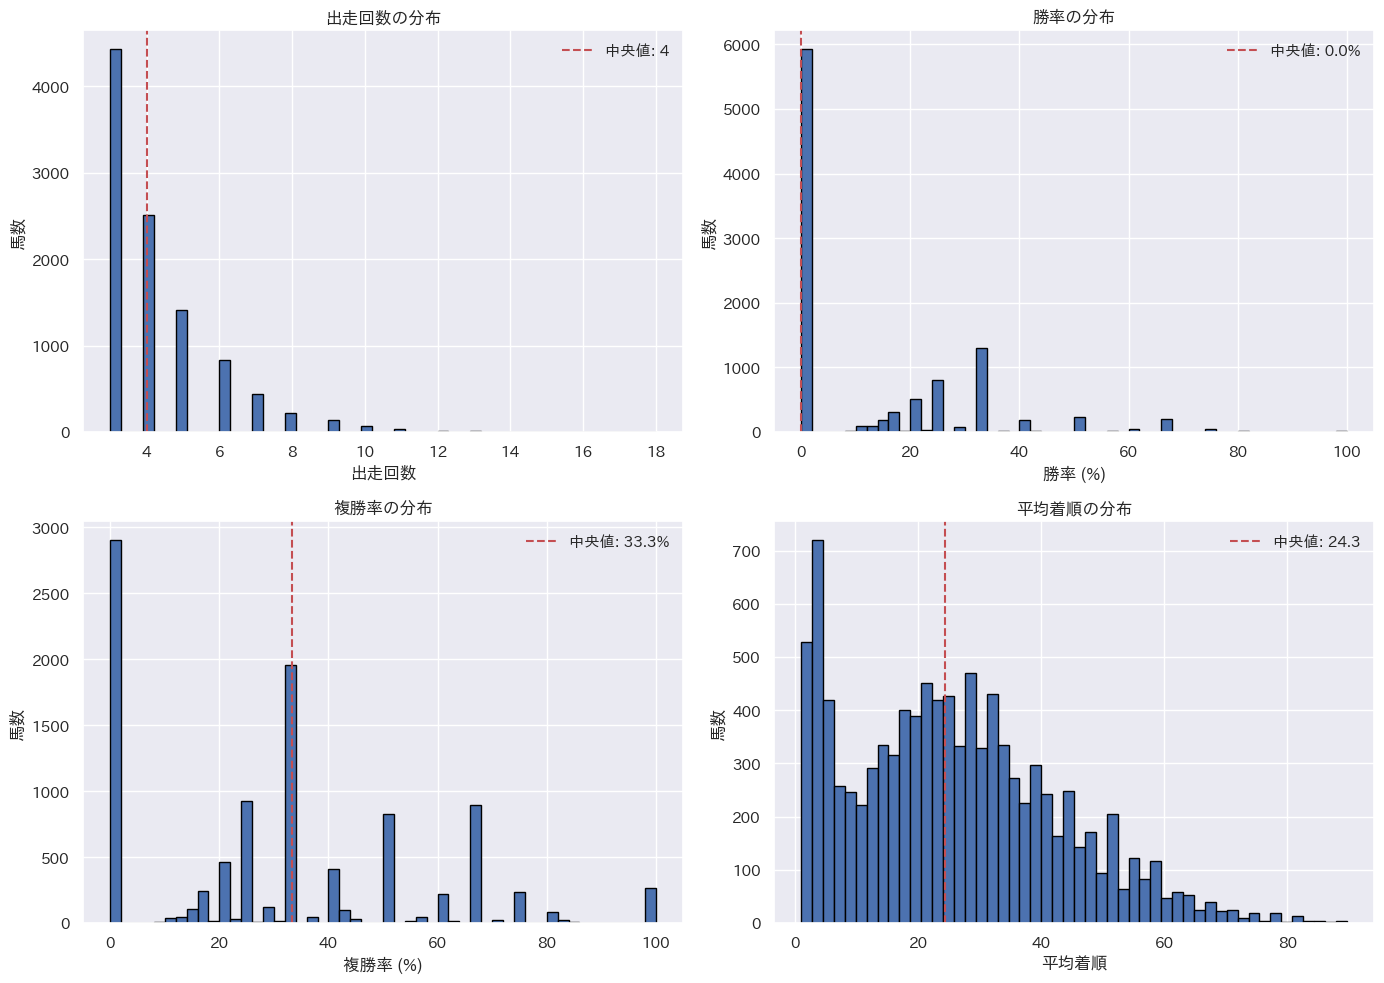

In [4]:
# 出走回数の分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 出走回数の分布
axes[0, 0].hist(df_horse_stats['race_count'], bins=50, edgecolor='black')
axes[0, 0].set_xlabel('出走回数')
axes[0, 0].set_ylabel('馬数')
axes[0, 0].set_title('出走回数の分布')
axes[0, 0].axvline(df_horse_stats['race_count'].median(), color='r', linestyle='--', label=f'中央値: {df_horse_stats["race_count"].median():.0f}')
axes[0, 0].legend()

# 勝率の分布
axes[0, 1].hist(df_horse_stats['win_rate'], bins=50, edgecolor='black')
axes[0, 1].set_xlabel('勝率 (%)')
axes[0, 1].set_ylabel('馬数')
axes[0, 1].set_title('勝率の分布')
axes[0, 1].axvline(df_horse_stats['win_rate'].median(), color='r', linestyle='--', label=f'中央値: {df_horse_stats["win_rate"].median():.1f}%')
axes[0, 1].legend()

# 複勝率の分布
axes[1, 0].hist(df_horse_stats['place_rate'], bins=50, edgecolor='black')
axes[1, 0].set_xlabel('複勝率 (%)')
axes[1, 0].set_ylabel('馬数')
axes[1, 0].set_title('複勝率の分布')
axes[1, 0].axvline(df_horse_stats['place_rate'].median(), color='r', linestyle='--', label=f'中央値: {df_horse_stats["place_rate"].median():.1f}%')
axes[1, 0].legend()

# 平均着順の分布
axes[1, 1].hist(df_horse_stats['avg_position'], bins=50, edgecolor='black')
axes[1, 1].set_xlabel('平均着順')
axes[1, 1].set_ylabel('馬数')
axes[1, 1].set_title('平均着順の分布')
axes[1, 1].axvline(df_horse_stats['avg_position'].median(), color='r', linestyle='--', label=f'中央値: {df_horse_stats["avg_position"].median():.1f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [5]:
# 勝率上位の馬
print('=== 勝率上位20馬（5戦以上） ===')
top_winners = df_horse_stats[df_horse_stats['race_count'] >= 5].nlargest(20, 'win_rate')
top_winners[['horse_id', 'race_count', 'win_count', 'win_rate', 'place_rate', 'avg_position']]

=== 勝率上位20馬（5戦以上） ===


,horse_id,race_count,win_count,win_rate,place_rate,avg_position
476,18110015,5,4,80.00,80.00,1.60
1040,13110043,5,4,80.00,100.00,1.20
1182,12102013,5,4,80.00,100.00,1.40
1455,16101938,5,4,80.00,100.00,1.20
2179,14105171,5,4,80.00,80.00,1.80
2970,15104649,5,4,80.00,80.00,1.60
2987,17110174,5,4,80.00,80.00,1.60
3878,21105077,5,4,80.00,100.00,1.40
387,18102091,6,4,66.67,66.67,16.00
2027,15101829,6,4,66.67,66.67,5.17


## 3. 脚質別分析

In [6]:
# コーナー通過順位から脚質を推定
query_running_style = f"""
SELECT 
    CASE 
        WHEN corner_position_4 <= 3 THEN '逃げ・先行'
        WHEN corner_position_4 <= 6 THEN '中団'
        WHEN corner_position_4 <= 10 THEN '差し'
        ELSE '追込'
    END as running_style,
    COUNT(*) as total,
    SUM(CASE WHEN goal_position = 1 THEN 1 ELSE 0 END) as win_count,
    SUM(CASE WHEN goal_position <= 3 THEN 1 ELSE 0 END) as place_count,
    AVG(goal_position) as avg_position
FROM `{PROJECT_ID}.raw.horse_results`
WHERE corner_position_4 IS NOT NULL
    AND goal_position IS NOT NULL AND goal_position > 0
GROUP BY running_style
ORDER BY avg_position
"""

try:
    df_running = client.query(query_running_style).to_dataframe()
    df_running['win_rate'] = df_running['win_count'] / df_running['total'] * 100
    df_running['place_rate'] = df_running['place_count'] / df_running['total'] * 100
    
    print('=== 脚質別成績 ===')
    display(df_running)
except Exception as e:
    print(f'Error: {e}')
    print('注: corner_position_4カラムが存在しない可能性があります')

Error: 400 Unrecognized name: corner_position_4 at [14:7]

Location: asia-northeast1
Job ID: e9fc6412-d43d-4ae9-b21b-6dbc647a9eec

注: corner_position_4カラムが存在しない可能性があります


Error: name 'df_running' is not defined


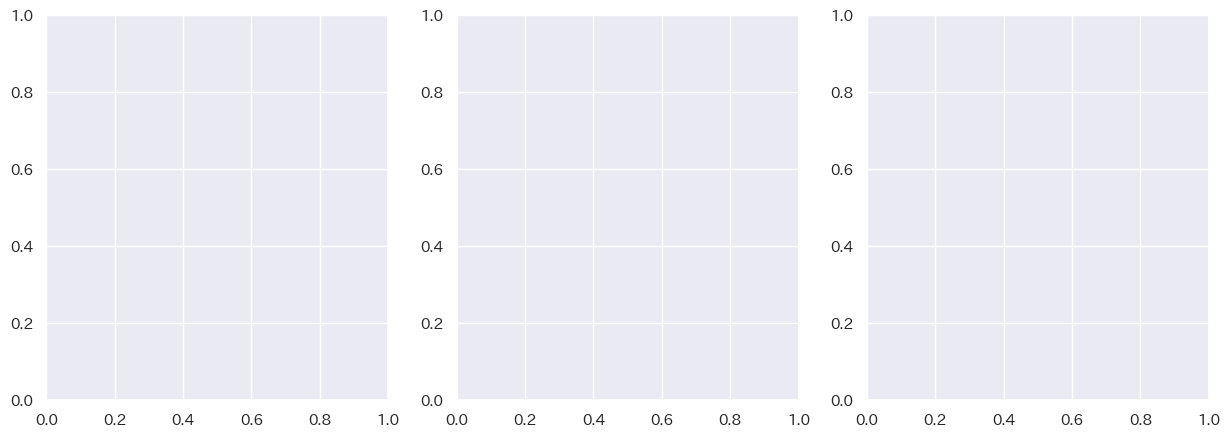

In [7]:
# 脚質別成績の可視化
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 勝率
    axes[0].bar(df_running['running_style'], df_running['win_rate'])
    axes[0].set_xlabel('脚質')
    axes[0].set_ylabel('勝率 (%)')
    axes[0].set_title('脚質別勝率')
    
    # 複勝率
    axes[1].bar(df_running['running_style'], df_running['place_rate'])
    axes[1].set_xlabel('脚質')
    axes[1].set_ylabel('複勝率 (%)')
    axes[1].set_title('脚質別複勝率')
    
    # レース数
    axes[2].bar(df_running['running_style'], df_running['total'])
    axes[2].set_xlabel('脚質')
    axes[2].set_ylabel('レース数')
    axes[2].set_title('脚質別レース数')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')

## 4. 上がり3Fの分析

In [8]:
# 上がり3Fと着順の関係
query_last3f = f"""
SELECT 
    last_3f_time,
    goal_position,
    base_popularity as popularity
FROM `{PROJECT_ID}.raw.horse_results`
WHERE last_3f_time IS NOT NULL
    AND last_3f_time > 30
    AND last_3f_time < 45
    AND goal_position IS NOT NULL AND goal_position > 0
LIMIT 50000
"""

try:
    df_last3f = client.query(query_last3f).to_dataframe()
    print(f'サンプル数: {len(df_last3f)}')
    df_last3f.describe()
except Exception as e:
    print(f'Error: {e}')

Error: 400 Unrecognized name: last_3f_time; Did you mean last_3f_gap? at [7:7]

Location: asia-northeast1
Job ID: e18ba67e-5163-4d87-a619-73f26d60b815



Error: name 'df_last3f' is not defined


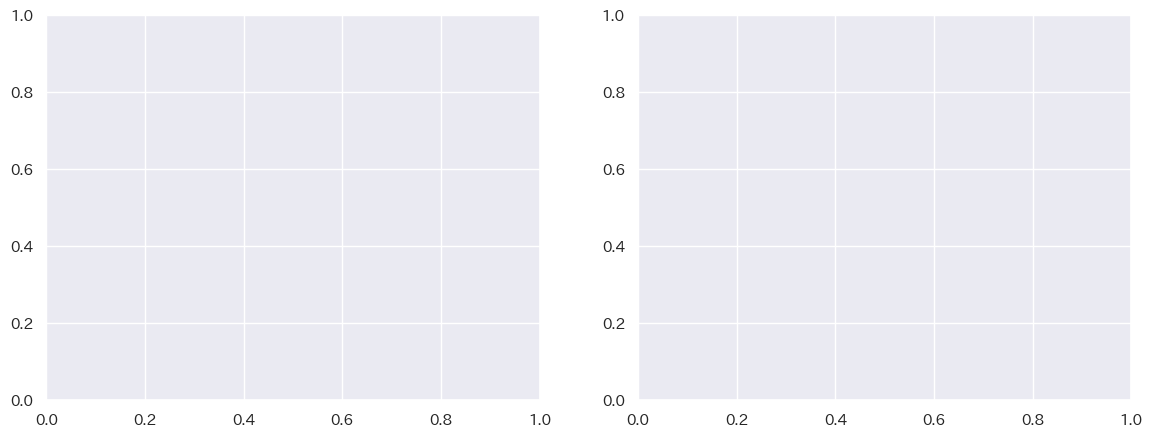

In [9]:
# 上がり3Fの分布
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 上がり3Fの分布
    axes[0].hist(df_last3f['last_3f_time'], bins=50, edgecolor='black')
    axes[0].set_xlabel('上がり3F (秒)')
    axes[0].set_ylabel('頻度')
    axes[0].set_title('上がり3Fの分布')
    axes[0].axvline(df_last3f['last_3f_time'].median(), color='r', linestyle='--', 
                    label=f'中央値: {df_last3f["last_3f_time"].median():.1f}秒')
    axes[0].legend()
    
    # 上がり3Fと着順の散布図
    axes[1].scatter(df_last3f['last_3f_time'], df_last3f['goal_position'], alpha=0.1)
    axes[1].set_xlabel('上がり3F (秒)')
    axes[1].set_ylabel('着順')
    axes[1].set_title('上がり3Fと着順の関係')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')

In [10]:
# 上がり3Fランク別の勝率
try:
    # 上がり3Fのランクを計算（レース内順位が取れない場合は絶対値で区分）
    df_last3f['last3f_category'] = pd.cut(df_last3f['last_3f_time'], 
                                           bins=[30, 33, 34, 35, 36, 37, 45],
                                           labels=['~33秒', '33-34秒', '34-35秒', '35-36秒', '36-37秒', '37秒~'])
    
    last3f_summary = df_last3f.groupby('last3f_category').agg({
        'goal_position': ['count', 'mean', lambda x: (x == 1).sum(), lambda x: (x <= 3).sum()]
    }).round(2)
    last3f_summary.columns = ['レース数', '平均着順', '勝利数', '複勝数']
    last3f_summary['勝率(%)'] = (last3f_summary['勝利数'] / last3f_summary['レース数'] * 100).round(1)
    last3f_summary['複勝率(%)'] = (last3f_summary['複勝数'] / last3f_summary['レース数'] * 100).round(1)
    
    print('=== 上がり3F別成績 ===')
    display(last3f_summary)
except Exception as e:
    print(f'Error: {e}')

Error: name 'df_last3f' is not defined


## 5. 休養期間の影響

In [11]:
# 休養期間別の成績を分析
# 注: 休養期間は特徴量として計算済みの場合はそれを使用
query_rest_days = f"""
WITH horse_races AS (
    SELECT 
        hr.horse_id,
        hr.race_id,
        ri.race_date,
        hr.goal_position,
        LAG(ri.race_date) OVER (PARTITION BY hr.horse_id ORDER BY ri.race_date) as prev_race_date
    FROM `{PROJECT_ID}.raw.horse_results` hr
    JOIN `{PROJECT_ID}.raw.race_info` ri ON hr.race_id = ri.race_id
    WHERE hr.goal_position IS NOT NULL AND hr.goal_position > 0
)
SELECT 
    CASE 
        WHEN DATE_DIFF(race_date, prev_race_date, DAY) <= 14 THEN '連闘~2週'
        WHEN DATE_DIFF(race_date, prev_race_date, DAY) <= 28 THEN '3-4週'
        WHEN DATE_DIFF(race_date, prev_race_date, DAY) <= 56 THEN '5-8週'
        WHEN DATE_DIFF(race_date, prev_race_date, DAY) <= 84 THEN '9-12週'
        WHEN DATE_DIFF(race_date, prev_race_date, DAY) <= 180 THEN '13-26週'
        ELSE '半年以上'
    END as rest_period,
    COUNT(*) as total,
    SUM(CASE WHEN goal_position = 1 THEN 1 ELSE 0 END) as win_count,
    SUM(CASE WHEN goal_position <= 3 THEN 1 ELSE 0 END) as place_count,
    AVG(goal_position) as avg_position
FROM horse_races
WHERE prev_race_date IS NOT NULL
GROUP BY rest_period
ORDER BY 
    CASE rest_period
        WHEN '連闘~2週' THEN 1
        WHEN '3-4週' THEN 2
        WHEN '5-8週' THEN 3
        WHEN '9-12週' THEN 4
        WHEN '13-26週' THEN 5
        ELSE 6
    END
"""

try:
    df_rest = client.query(query_rest_days).to_dataframe()
    df_rest['win_rate'] = df_rest['win_count'] / df_rest['total'] * 100
    df_rest['place_rate'] = df_rest['place_count'] / df_rest['total'] * 100
    
    print('=== 休養期間別成績 ===')
    display(df_rest)
except Exception as e:
    print(f'Error: {e}')

=== 休養期間別成績 ===


,rest_period,total,win_count,place_count,avg_position,win_rate,place_rate
0,連闘~2週,14,2,7,29.14,14.29,50.00
1,3-4週,24,5,10,29.50,20.83,41.67
2,5-8週,100,11,26,21.69,11.00,26.00
3,9-12週,185,27,66,24.02,14.59,35.68
4,13-26週,429,59,127,25.20,13.75,29.60
5,半年以上,1499,173,388,26.19,11.54,25.88


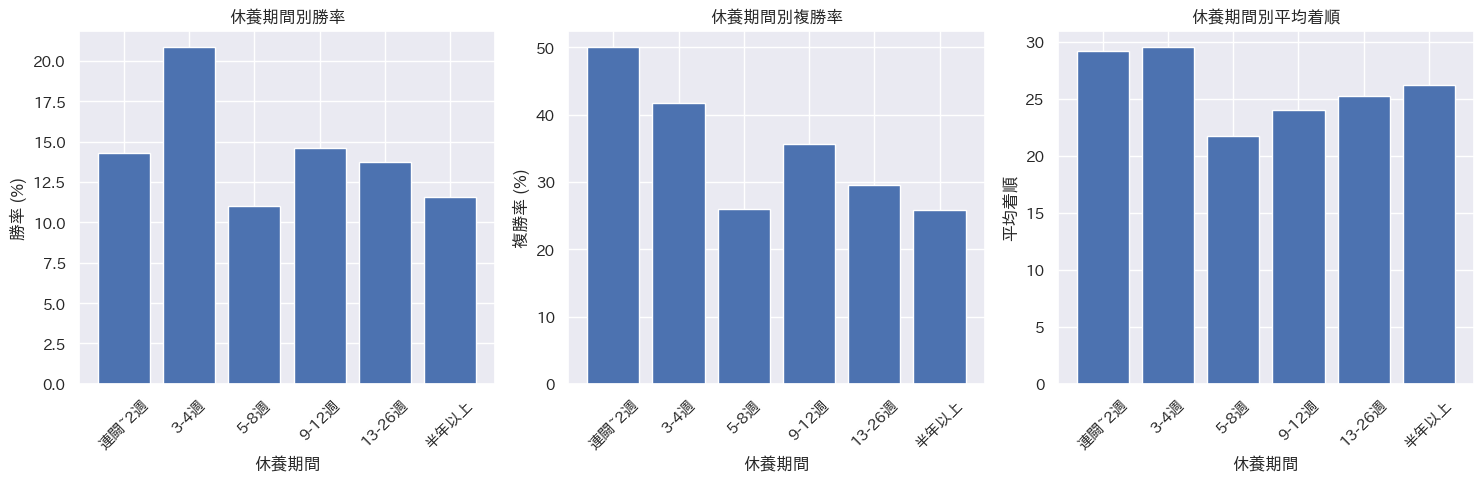

In [12]:
# 休養期間別成績の可視化
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 勝率
    axes[0].bar(df_rest['rest_period'], df_rest['win_rate'])
    axes[0].set_xlabel('休養期間')
    axes[0].set_ylabel('勝率 (%)')
    axes[0].set_title('休養期間別勝率')
    axes[0].tick_params(axis='x', rotation=45)
    
    # 複勝率
    axes[1].bar(df_rest['rest_period'], df_rest['place_rate'])
    axes[1].set_xlabel('休養期間')
    axes[1].set_ylabel('複勝率 (%)')
    axes[1].set_title('休養期間別複勝率')
    axes[1].tick_params(axis='x', rotation=45)
    
    # 平均着順
    axes[2].bar(df_rest['rest_period'], df_rest['avg_position'])
    axes[2].set_xlabel('休養期間')
    axes[2].set_ylabel('平均着順')
    axes[2].set_title('休養期間別平均着順')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Error: {e}')

## 6. 外れ値の検出

In [13]:
# 数値カラムの外れ値を検出
def detect_outliers_iqr(df, column):
    """IQR法で外れ値を検出"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return {
        'column': column,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_pct': len(outliers) / len(df) * 100
    }

# 馬成績データの外れ値検出
outlier_results = []
for col in ['race_count', 'win_rate', 'place_rate', 'avg_position']:
    result = detect_outliers_iqr(df_horse_stats, col)
    outlier_results.append(result)

outlier_df = pd.DataFrame(outlier_results)
print('=== 外れ値検出結果（IQR法） ===')
outlier_df

=== 外れ値検出結果（IQR法） ===


,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,race_count,0.00,8.00,273,2.70
1,win_rate,-37.50,62.50,270,2.67
2,place_rate,-75.00,125.00,0,0.00
3,avg_position,-23.25,72.08,72,0.71


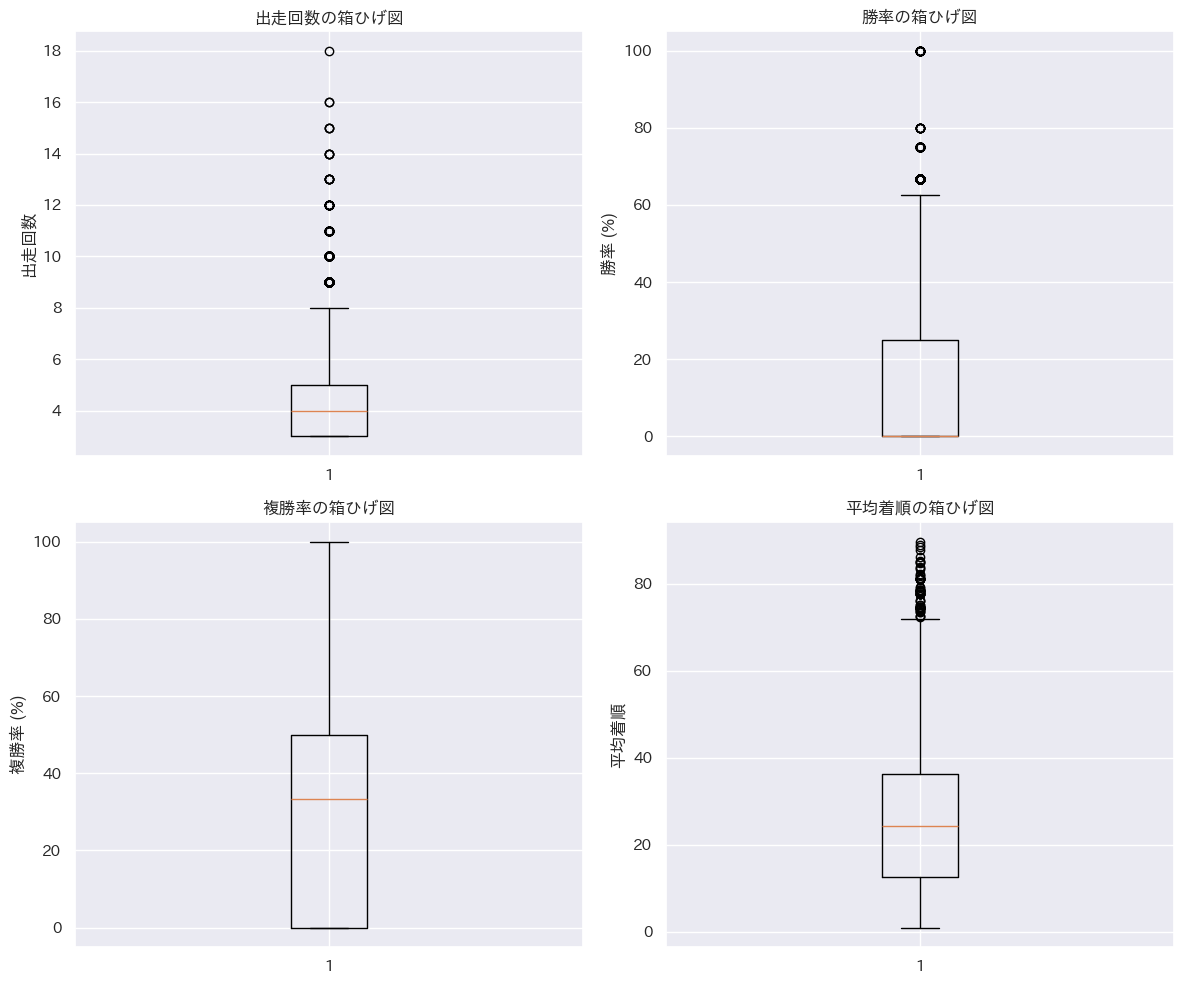

In [14]:
# 箱ひげ図で外れ値を可視化
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 出走回数
axes[0, 0].boxplot(df_horse_stats['race_count'])
axes[0, 0].set_title('出走回数の箱ひげ図')
axes[0, 0].set_ylabel('出走回数')

# 勝率
axes[0, 1].boxplot(df_horse_stats['win_rate'])
axes[0, 1].set_title('勝率の箱ひげ図')
axes[0, 1].set_ylabel('勝率 (%)')

# 複勝率
axes[1, 0].boxplot(df_horse_stats['place_rate'])
axes[1, 0].set_title('複勝率の箱ひげ図')
axes[1, 0].set_ylabel('複勝率 (%)')

# 平均着順
axes[1, 1].boxplot(df_horse_stats['avg_position'])
axes[1, 1].set_title('平均着順の箱ひげ図')
axes[1, 1].set_ylabel('平均着順')

plt.tight_layout()
plt.show()

In [15]:
# 外れ値の馬を特定（出走回数が極端に多い馬）
high_race_count = df_horse_stats[df_horse_stats['race_count'] > df_horse_stats['race_count'].quantile(0.99)]
print(f'=== 出走回数上位1%の馬 ({len(high_race_count)}頭) ===')
high_race_count.sort_values('race_count', ascending=False).head(10)

=== 出走回数上位1%の馬 (65頭) ===


,horse_id,race_count,win_count,place_count,avg_position,best_position,worst_position,win_rate,place_rate
8647,10101988,18,0,0,60.72,6,93,0.00,0.00
461,15100822,16,3,4,23.00,1,91,18.75,25.00
1432,13105727,16,2,6,18.12,1,81,12.50,37.50
5477,16100742,15,0,3,42.93,2,82,0.00,20.00
1352,14100555,15,2,7,9.80,1,61,13.33,46.67
2368,17104266,15,1,3,27.33,1,81,6.67,20.00
680,13102133,14,3,7,11.93,1,52,21.43,50.00
1203,13101930,14,1,2,31.43,1,92,7.14,14.29
5950,13103403,14,0,4,21.71,2,91,0.00,28.57
4090,13103941,14,1,7,6.50,1,41,7.14,50.00


## まとめ

このノートブックでは以下の分析を行いました：

1. **馬の成績分布**: 出走回数、勝率、複勝率、平均着順の分布
2. **脚質別分析**: 逃げ・先行、中団、差し、追込の成績比較
3. **上がり3Fの分析**: 上がりタイムと着順の関係
4. **休養期間の影響**: 休養期間と成績の関係
5. **外れ値の検出**: IQR法による異常値の特定

### 主な発見
- 前に位置する脚質（逃げ・先行）が有利な傾向
- 上がり3Fが速いほど好成績
- 適度な休養期間（3-8週）が好成績につながる傾向

### 次のステップ
- `04_feature_correlation.ipynb`: 特徴量の相関分析